# Step 2-3: Sanitization and Testing & Utility and Privacy Analysis

In [1]:
pip install presidio-analyzer presidio-anonymizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.8 MB/s eta 0:00:00


In [2]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Cosine Similarity

In [3]:
import spacy
import logging
import pandas as pd
from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern
from presidio_anonymizer import AnonymizerEngine

nlp = spacy.load("en_core_web_lg")
logging.getLogger("presidio-analyzer").setLevel(logging.ERROR)

# setup engines
baseline_analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

improved_analyzer = AnalyzerEngine()

money_pattern = Pattern(name="money", regex=r"\$\d+(?:,\d{3})*(?:\.\d+)?(?:[kKmMbB])?", score=0.8)
improved_analyzer.registry.add_recognizer(PatternRecognizer(supported_entity="FINANCIAL_AMOUNT", patterns=[money_pattern]))

username_pattern = Pattern(name="username", regex=r"admin_[a-zA-Z0-9]+", score=0.8)
improved_analyzer.registry.add_recognizer(PatternRecognizer(supported_entity="USERNAME", patterns=[username_pattern]))

deny_list = [
    "St. Jude’s", "Stage 2 Hypertension", "Lisinopril", "Netflix",
    "Google", "CloudStream Inc.", "daughter", "'timeout'",
    "4th-grade", "implications", "2025"
]

improved_analyzer.registry.add_recognizer(PatternRecognizer(supported_entity="SENSITIVE_TERM", deny_list=deny_list))

address_pattern = Pattern(name="street_address", regex=r"\d+\s[A-Z][a-zA-Z]+\s(?:Lane|St|Street|Ave|Avenue|Blvd|Road|Rd)", score=0.85)
improved_analyzer.registry.add_recognizer(PatternRecognizer(supported_entity="STREET_ADDRESS", patterns=[address_pattern]))

student_id_pattern = Pattern(name="student_id", regex=r"\b\d{6}\b", score=0.9)
improved_analyzer.registry.add_recognizer(PatternRecognizer(supported_entity="STUDENT_ID", patterns=[student_id_pattern]))

# 4. define the samples
samples = [
    "I was seen at St. Jude’s yesterday for my Stage 2 Hypertension. Can you explain if the Lisinopril dosage my doctor, Dr. Aris, prescribed is standard?",
    "Draft a memo regarding the acquisition of CloudStream Inc. for $450M. The lead negotiator is Sarah Jenkins from our Austin office, and we need to finalize this by Friday, the 14th.",
    "We are considering Elena Rodriguez for the Senior DevOps role. She currently makes $165,000 at Netflix and lives in Los Gatos. Is this competitive?",
    "I can't log into the production server at 192.168.1.45. My username is admin_jake, and I keep getting a 'timeout' error.",
    "Please summarize the IEP for student ID 883920. Tommy Miller is struggling with reading comprehension in Ms. Gable’s 4th-grade class.",
    "Generate a listing description for 45 Oakhaven Lane. The owner wants to highlight the new roof and the proximity to Google’s headquarters.",
    "Remind me to pick up my daughter from daycare at 4:30 PM. Then, book a table for two.",
    "I have $50,000 in my savings account, and I’m worried about the tax implications for my 2025 filing after moving states."
]

for i, text in enumerate(samples, 1):
    doc_original = nlp(text)

    # baseline processing
    base_analysis = baseline_analyzer.analyze(text=text, language='en')
    base_sanitized = anonymizer.anonymize(text=text, analyzer_results=base_analysis).text
    base_score = doc_original.similarity(nlp(base_sanitized))

    # improved processing
    imp_analysis = improved_analyzer.analyze(text=text, language='en')
    imp_sanitized = anonymizer.anonymize(text=text, analyzer_results=imp_analysis).text
    imp_score = doc_original.similarity(nlp(imp_sanitized))

    diff = base_score - imp_score

    # print results formated
    print(f"--- Sample {i} ---")
    print(f"Original Text   : {text}")
    print(f"Baseline Output : {base_sanitized}")
    print(f"Improved Output : {imp_sanitized}")
    print(f"Baseline Score  : {base_score:.4f}")
    print(f"Improved Score  : {imp_score:.4f}")
    print(f"Score Difference: {diff:.4f}\n")

--- Sample 1 ---
Original Text   : I was seen at St. Jude’s yesterday for my Stage 2 Hypertension. Can you explain if the Lisinopril dosage my doctor, Dr. Aris, prescribed is standard?
Baseline Output : I was seen at St. Jude’s <DATE_TIME> for my Stage 2 Hypertension. Can you explain if the Lisinopril dosage my doctor, Dr. <PERSON>, prescribed is standard?
Improved Output : I was seen at <SENSITIVE_TERM> <DATE_TIME> for my <SENSITIVE_TERM>. Can you explain if the <SENSITIVE_TERM> dosage my doctor, Dr. <PERSON>, prescribed is standard?
Baseline Score  : 0.9688
Improved Score  : 0.8314
Score Difference: 0.1373

--- Sample 2 ---
Original Text   : Draft a memo regarding the acquisition of CloudStream Inc. for $450M. The lead negotiator is Sarah Jenkins from our Austin office, and we need to finalize this by Friday, the 14th.
Baseline Output : Draft a memo regarding the acquisition of CloudStream Inc. for $450M. The lead negotiator is <PERSON> from our <LOCATION> office, and we need to fina

### Visualization: Cosine Similarity

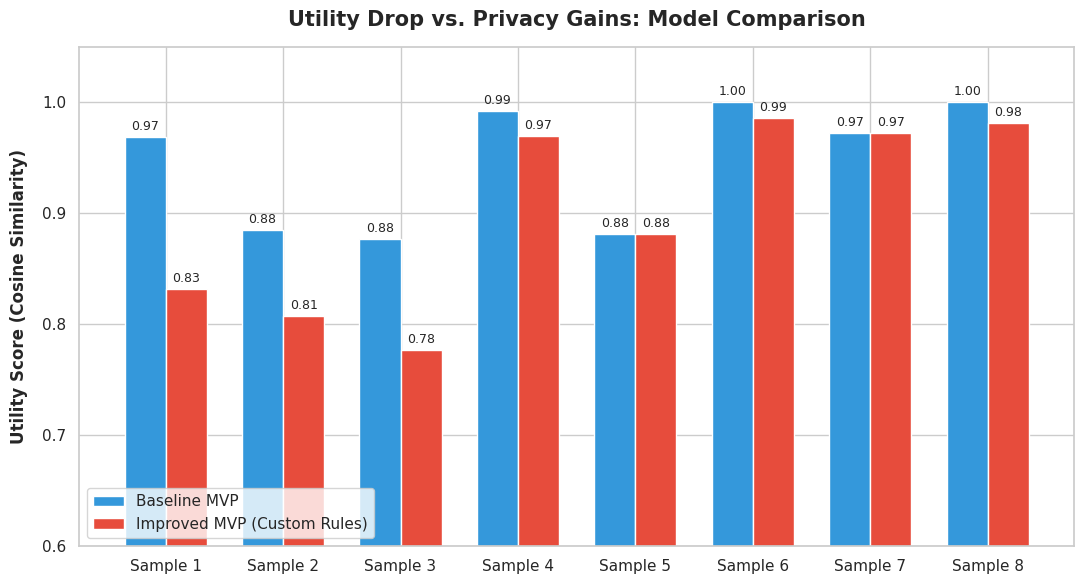

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# data from previous
samples = [f"Sample {i}" for i in range(1, 9)]
baseline_scores = [0.9688, 0.8844, 0.8764, 0.9920, 0.8815, 1.0000, 0.9723, 1.0000]
improved_scores = [0.8314, 0.8071, 0.7766, 0.9693, 0.8815, 0.9857, 0.9723, 0.9810]

x = np.arange(len(samples))  # label locations
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# plot bars
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline MVP', color='#3498db')
rects2 = ax.bar(x + width/2, improved_scores, width, label='Improved MVP (Custom Rules)', color='#e74c3c')

# add annotations and labels
ax.set_ylabel('Utility Score (Cosine Similarity)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Utility Drop vs. Privacy Gains: Model Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(samples, fontsize=11)
ax.set_ylim(0.6, 1.05)
ax.legend(loc='lower left', fontsize=11, frameon=True)

# attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('utility_comparison.png', dpi=300)
plt.show()